Our goal is to predict the price (target) of a laptop based on 10 variables (features).

# Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Importing necessary libraries.

In [54]:
df = pd.read_csv("laptop_prices.csv", encoding='latin-1')

Importing our data (Laptop Prices dataset).

In [7]:
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


Previewing the dataset.

# Preparing the data

In [10]:
EURO_TO_CAD = 1.55
df['Price'] = df['Price_euros'].apply(lambda p : round(p * EURO_TO_CAD, 2))

For our purposes we want the prices to be in CAD, not Euros.

In [12]:
df = df.drop(columns=['laptop_ID', 'Price_euros'])
df = df.rename(columns={'Cpu' : 'CPU', 'Gpu' : 'GPU', 'OpSys' : 'OS', 'Inches' : 'ScreenSize', 'Ram' : 'RAM', 'ScreenResolution' : 'Resolution'})
df['Weight'] = df["Weight"].str.replace("kg", "").astype(float)
df['RAM'] = df["RAM"].str.replace("GB", "").astype(float)

Since we already know the units of these columns, we can rename them to make them easier to work with. Additionally, we want the Weight and RAM columns to be numeric.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Company     1303 non-null   object 
 1   Product     1303 non-null   object 
 2   TypeName    1303 non-null   object 
 3   ScreenSize  1303 non-null   float64
 4   Resolution  1303 non-null   object 
 5   CPU         1303 non-null   object 
 6   RAM         1303 non-null   float64
 7   Memory      1303 non-null   object 
 8   GPU         1303 non-null   object 
 9   OS          1303 non-null   object 
 10  Weight      1303 non-null   float64
 11  Price       1303 non-null   float64
dtypes: float64(4), object(8)
memory usage: 122.3+ KB


This shows us that no columns have any missing values. ScreenSize, RAM, Weight, and Price will be treated as numerical variables since they are of the float64 type while the rest are typed as object.

In [16]:
numerical_cols = df.select_dtypes(include=['float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [17]:
df.duplicated().sum()

28

There are 28 duplicates in the DataFrame so we remove them:

In [19]:
df = df.drop_duplicates()

# Comparing  all the numeric (and some categorical) feature variables to Price

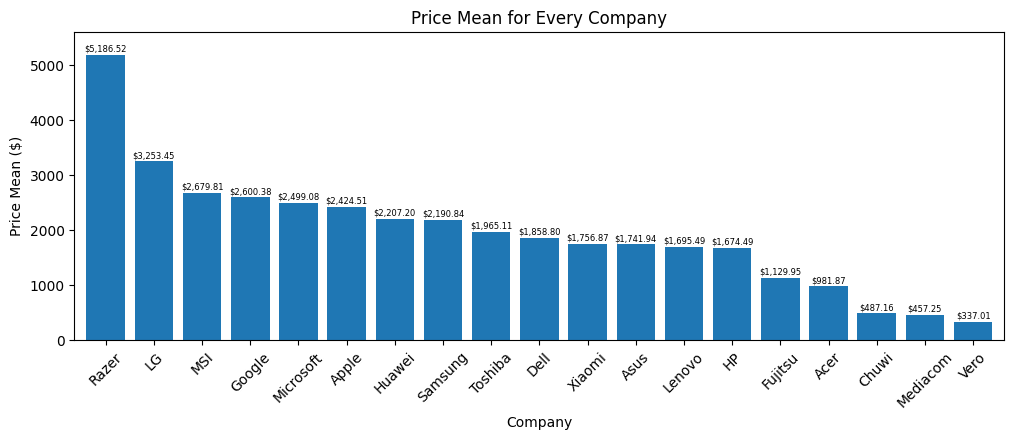

In [21]:
company_groups = df.groupby('Company')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,4))
company_groups.plot(kind='bar', width=0.8)
plt.xticks(rotation=45, ha='center')
plt.ylim(0,5600)
plt.ylabel('Price Mean ($)')
plt.title('Price Mean for Every Company')
for i, n in enumerate(company_groups.values):
    plt.text(i, n + 60, f"${n:,.2f}", ha='center', fontsize=6)
plt.show()

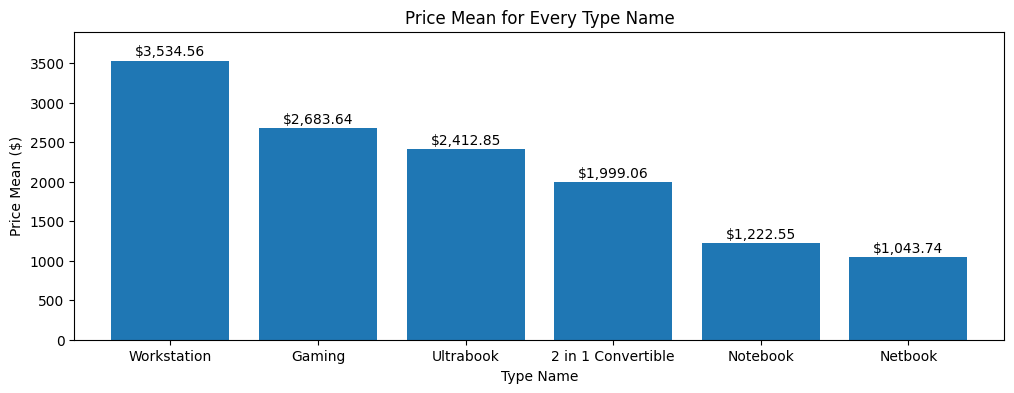

In [22]:
typename_groups = df.groupby('TypeName')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,4))
typename_groups.plot(kind='bar', width=0.8)
plt.xticks(rotation=0, ha='center')
plt.ylim(0,3900)
plt.ylabel('Price Mean ($)')
plt.xlabel('Type Name')
plt.title('Price Mean for Every Type Name')
for i, n in enumerate(typename_groups.values):
    plt.text(i, n + 60, f"${n:,.2f}", ha='center')
plt.show()

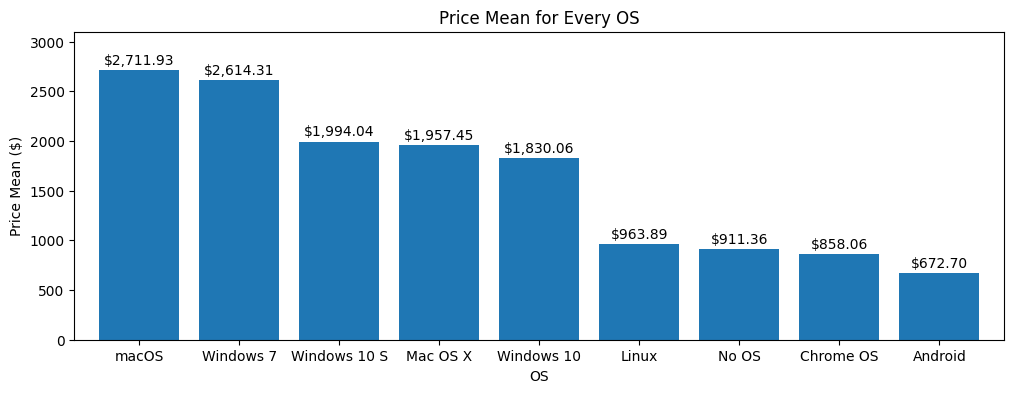

In [23]:
os_groups = df.groupby('OS')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,4))
os_groups.plot(kind='bar', width=0.8)
plt.xticks(rotation=0, ha='center')
plt.ylim(0,3100)
plt.ylabel('Price Mean ($)')
plt.title('Price Mean for Every OS')
for i, n in enumerate(os_groups.values):
    plt.text(i, n + 60, f"${n:,.2f}", ha='center')
plt.show()

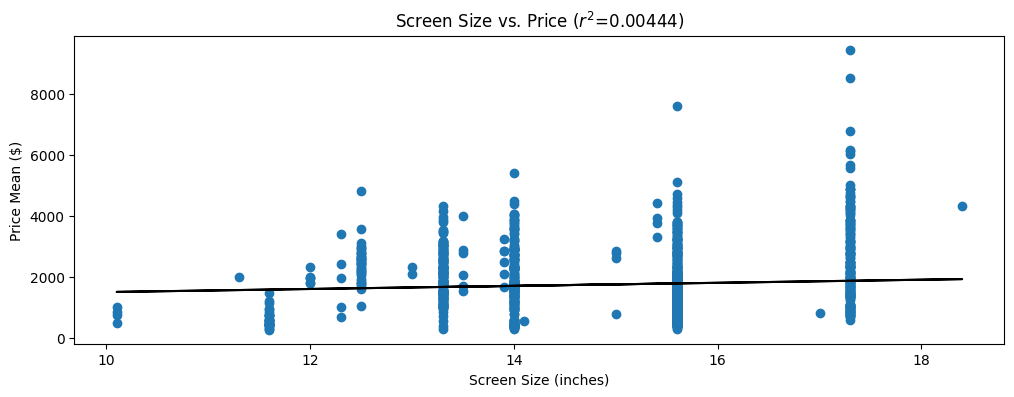

In [24]:
from scipy import stats

plt.figure(figsize=(12,4))
x = df['ScreenSize']
y = df['Price']
plt.scatter(x, y)
slope, intercept, r, p_value, std_err = stats.linregress(x, y)
line_of_best_fit = slope * x + intercept
plt.plot(x, line_of_best_fit, color='black')
plt.title("Screen Size vs. Price ($r^2$=" + str(round(r**2,5)) + ")")
plt.xlabel('Screen Size (inches)')
plt.ylabel('Price Mean ($)')
plt.show()

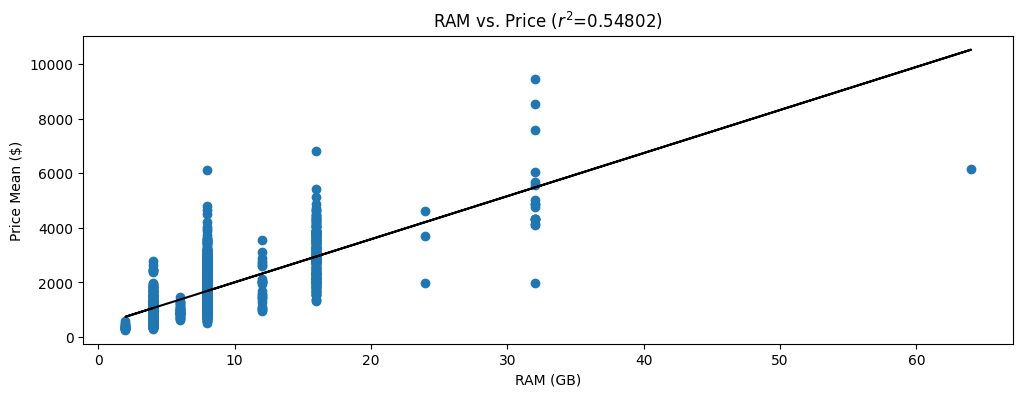

In [25]:
plt.figure(figsize=(12,4))
x = df['RAM']
y = df['Price']
plt.scatter(x, y)
slope, intercept, r, p_value, std_err = stats.linregress(x, y)
line_of_best_fit = slope * x + intercept
plt.plot(x, line_of_best_fit, color='black')
plt.title("RAM vs. Price ($r^2$=" + str(round(r**2,5)) + ")")
plt.xlabel('RAM (GB)')
plt.ylabel('Price Mean ($)')
plt.show()

The $r^2$ value is not bad at all, so RAM likely has a bigger influence on Price than Screen Size or Weight do.

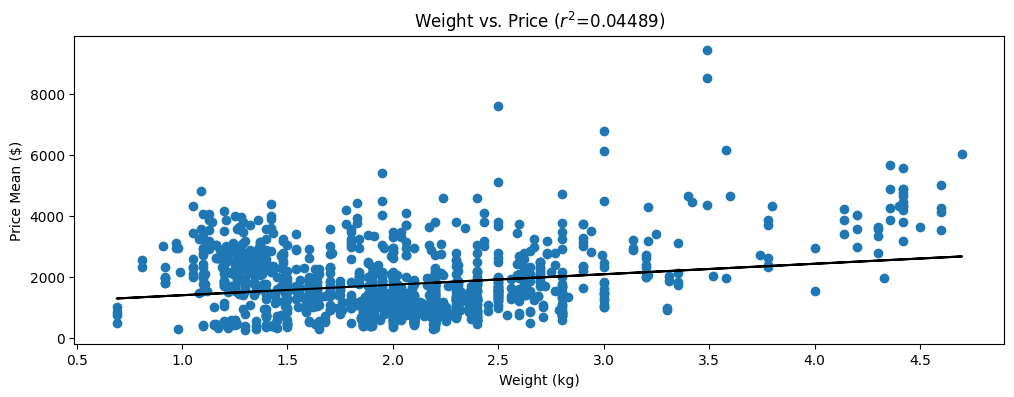

In [27]:
plt.figure(figsize=(12,4))
x = df['Weight']
y = df['Price']
plt.scatter(x, y)
slope, intercept, r, p_value, std_err = stats.linregress(x, y)
line_of_best_fit = slope * x + intercept
plt.plot(x, line_of_best_fit, color='black')
plt.title("Weight vs. Price ($r^2$=" + str(round(r**2,5)) + ")")
plt.xlabel('Weight (kg)')
plt.ylabel('Price Mean ($)')
plt.show()

# Predicting Price

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns=["Price"]) 
y = df["Price"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["float64"]).columns.tolist()

encoder = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', encoder, categorical_cols),
        ('numerical', 'passthrough', numerical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

total_mse = 0
total_r2 = 0

n = 10
for i in range(n):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    total_mse += mse
    total_r2 += r2

print(f"Average Mean Squared Error: {total_mse/n}")
print(f"Average R² Score: {total_r2/n:.4f}")

Average Mean Squared Error: 285828.560569571
Average R² Score: 0.7571


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=["Price"]) 
y = df["Price"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["float64"]).columns.tolist()

encoder = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', encoder, categorical_cols),
        ('numerical', 'passthrough', numerical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor())
])

total_mse = 0
total_r2 = 0

n = 10
for i in range(n):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    total_mse += mse
    total_r2 += r2

print(f"Average Mean Squared Error: {total_mse/n}")
print(f"Average R² Score: {total_r2/n:.4f}")

Average Mean Squared Error: 331620.1122705392
Average R² Score: 0.7118


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=["Price"]) 
y = df["Price"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["float64"]).columns.tolist()

encoder = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', encoder, categorical_cols),
        ('numerical', 'passthrough', numerical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor())
])

total_mse = 0
total_r2 = 0

n = 10
for i in range(n):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    total_mse += mse
    total_r2 += r2

print(f"Average Mean Squared Error: {total_mse/n}")
print(f"Average R² Score: {total_r2/n:.4f}")

Average Mean Squared Error: 200816.2105338863
Average R² Score: 0.8130


Since RandomForestRegressor has a higher $R^2$ score than the other two models, this is the one we will use for predictions.